# Метод обратного распространения ошибки

## Теория

Обратное распространение ошибки (Backpropagation) – один из способов обучения нейронной сети, который корректирует веса для минимизации ошибки.

Стохастический градиентный спуск (SGD) – итерационный метод, который обучает нейронную сеть, двигаясь в сторону уменьшения ошибки. Вместо того чтобы ждать, пока сеть проитерируется по всем данным и вычислит идеальный градиент (что долго), SGD обновляет веса на основе одного примера или небольшой группы примеров.

Вместе они позволяют обучить сеть на больших наборах данных и добиться высокой точности предсказаний.

#### В каких задачах применяется?

- Классификация изображений – сеть учится отличать кошек от собак.
- Обработка текста – сеть понимает смысл текста или переводит язык.
- Рекомендательные системы – сеть предсказывает, какой фильм понравится пользователю.
- Игра в шахматы или Go – сеть учится делать оптимальные ходы.

и др.

### Общая схема работы

1. Подаём данные на вход нейронной сети -> Получаем её предсказание.
2. Сравниваем её предсказание с правильным ответом -> Считаем ошибку.
3. С помощью Backpropagation и SGD меняем веса так, чтобы попытаться уменьшить эту ошибку.
4. Повторяя пункты 1-3 ожидаем увидеть обучение нейронной сети.

#### 1. Прямое распространение (Forward Pass)

На вход подаётся вектор $x$. Для каждого слоя сети вычисляется линейная комбинация входов и весов:

$$𝑧^{(𝑙)}=𝑊^{(𝑙)}𝑎^{(𝑙−1)}+𝑏^{(𝑙)}$$

где $𝑎^{(𝑙−1)}$ — выход предыдущего слоя, $𝑊^{(𝑙)}$ — матрица весов, $𝑏^{(𝑙)}$ — вектор смещения.

И применяется нелинейная функция активации $\sigma$:

$$𝑎^{(𝑙)}=\sigma(𝑧^{(𝑙)})$$

На последнем слое получаем предсказание сети $\hat y$.

#### 2. Вычисление ошибки (Loss)

Сравниваем предсказание $\hat y$ с истинным значением $y$ с помощью функции потерь $L(\hat y, y)$. В нашем случае мы будем использовать кросс-энтропию для задачи классификации: 

$$L(\hat y, y)=−\sum_{i=1}^{C}y_{i}\log(\hat y_i)$$

где $C$ — количество классов, $y_i=1$ для правильного класса и $0$ для остальных, $\hat y_i$ — предсказанная сетью вероятность класса.

#### 3. Обратное распространение ошибки (Backpropagation) стохастическим градиентным спуском (SGD)

Для последнего слоя вычисляем градиент потерь по активациям:

$$\delta^{(L)}=\frac{\partial L​}{\partial z^{(L)}}=\frac{\partial L​}{\partial a^{(L)}}\odot\sigma^\prime(z^{(L)})$$

где $\odot$ — поэлементное умножение.

Для каждого предыдущего слоя:

$$\delta^{(l)}=(W^{(l+1)})^T\delta^{(l+1)}\odot\sigma^\prime(z^{(L)})$$

Градиенты по весам и смещениям:

$$\frac{\partial L}{\partial W^{(l)}}=\delta^{(l)}(a^{(l-1)})^T,\quad\frac{\partial L}{\partial b^{(l)}}=\delta^{(l)}$$

Для каждого мини-батча веса и смещения обновляются по формуле:

$$W^{(l)}=W^{(l)}-\eta\frac{\partial L}{\partial W^{(l)}},\quad b^{(l)}=b^{(l)}-\eta\frac{\partial L}{\partial b^{(l)}}$$

где $\eta$ — скорость обучения (learning rate). Обновление происходит не по всей обучающей выборке, а по одному мини-батчу.

### Конфигурация нейронной сети

1. Входной слой:
- Содержит w x h нейронов, что соответствует разрешению изображения из набора MNIST т.е. 28 x 28
- Не содержит функции активации

2. Скрытый слой:
- На вход подаётся 28 x 28 значений
- Содержит s нейронов
- Функция активации ReLU:

$$ReLU(x)=\max(0, x)$$

3. Выходной слой:
- На вход подаётся s значений
- Содержит k нейронов, что соответствует количеству классов изображений т.е. 10
- Функция активации Softmax:

$$Softmax(z_i)=\frac{e^{z_i}}{\sum_{j=1}^Ke^{z_j}}$$

### Градиент ошибки на последнем слое

Давайте посмотрим внимательнее на последний слой нашей нейронной сети. Здесь мы используем функцию активации Softmax и вычисляем функцию ошибки как кросс-энтропию. Попробуем найти градиент $\frac{\partial L}{\partial z_i}$ в этом случае. Производная softmax:

$$\frac{\partial\hat y_k}{\partial z_i}=\hat y_k(\delta_{ik}-\hat y_k)$$

Тогда

$$\frac{\partial L}{\partial z_i}=\sum_k\frac{\partial L}{\partial\hat y_k}\frac{\partial\hat y_k}{\partial z_i}$$
$$\frac{\partial L}{\partial z_i}=\sum_k(-\frac{y_k}{\hat y_k})\hat y_k(\delta_{ik}-\hat y_k)$$
$$\frac{\partial L}{\partial z_i}=-\sum_k y_k(\delta_{ik}-\hat y_k)$$
$$\frac{\partial L}{\partial z_i}=-y_i+\hat y_i\sum_k y_k$$

Но

$$\sum_k y_k = 1$$

Итого

$$\frac{\partial L}{\partial z_i}=\hat y_i-y_i$$

Получается, что градиент ошибки на последнем слое — это просто разница предсказания и истинного значения. Это значительно упрощает вычисления.

## Реализация (наконец-то)

### Датасет

Загрузим набор данных MNIST

In [1]:
import kagglehub

input_path = kagglehub.dataset_download("hojjatk/mnist-dataset")

d:\Code\Repositories\deep-learning-course-practice-2025\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Выведем несколько изображений с их метками классов, чтобы убедиться, что загрузка прошла успешно. (Копипаст со страницы kaggle)

In [2]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        



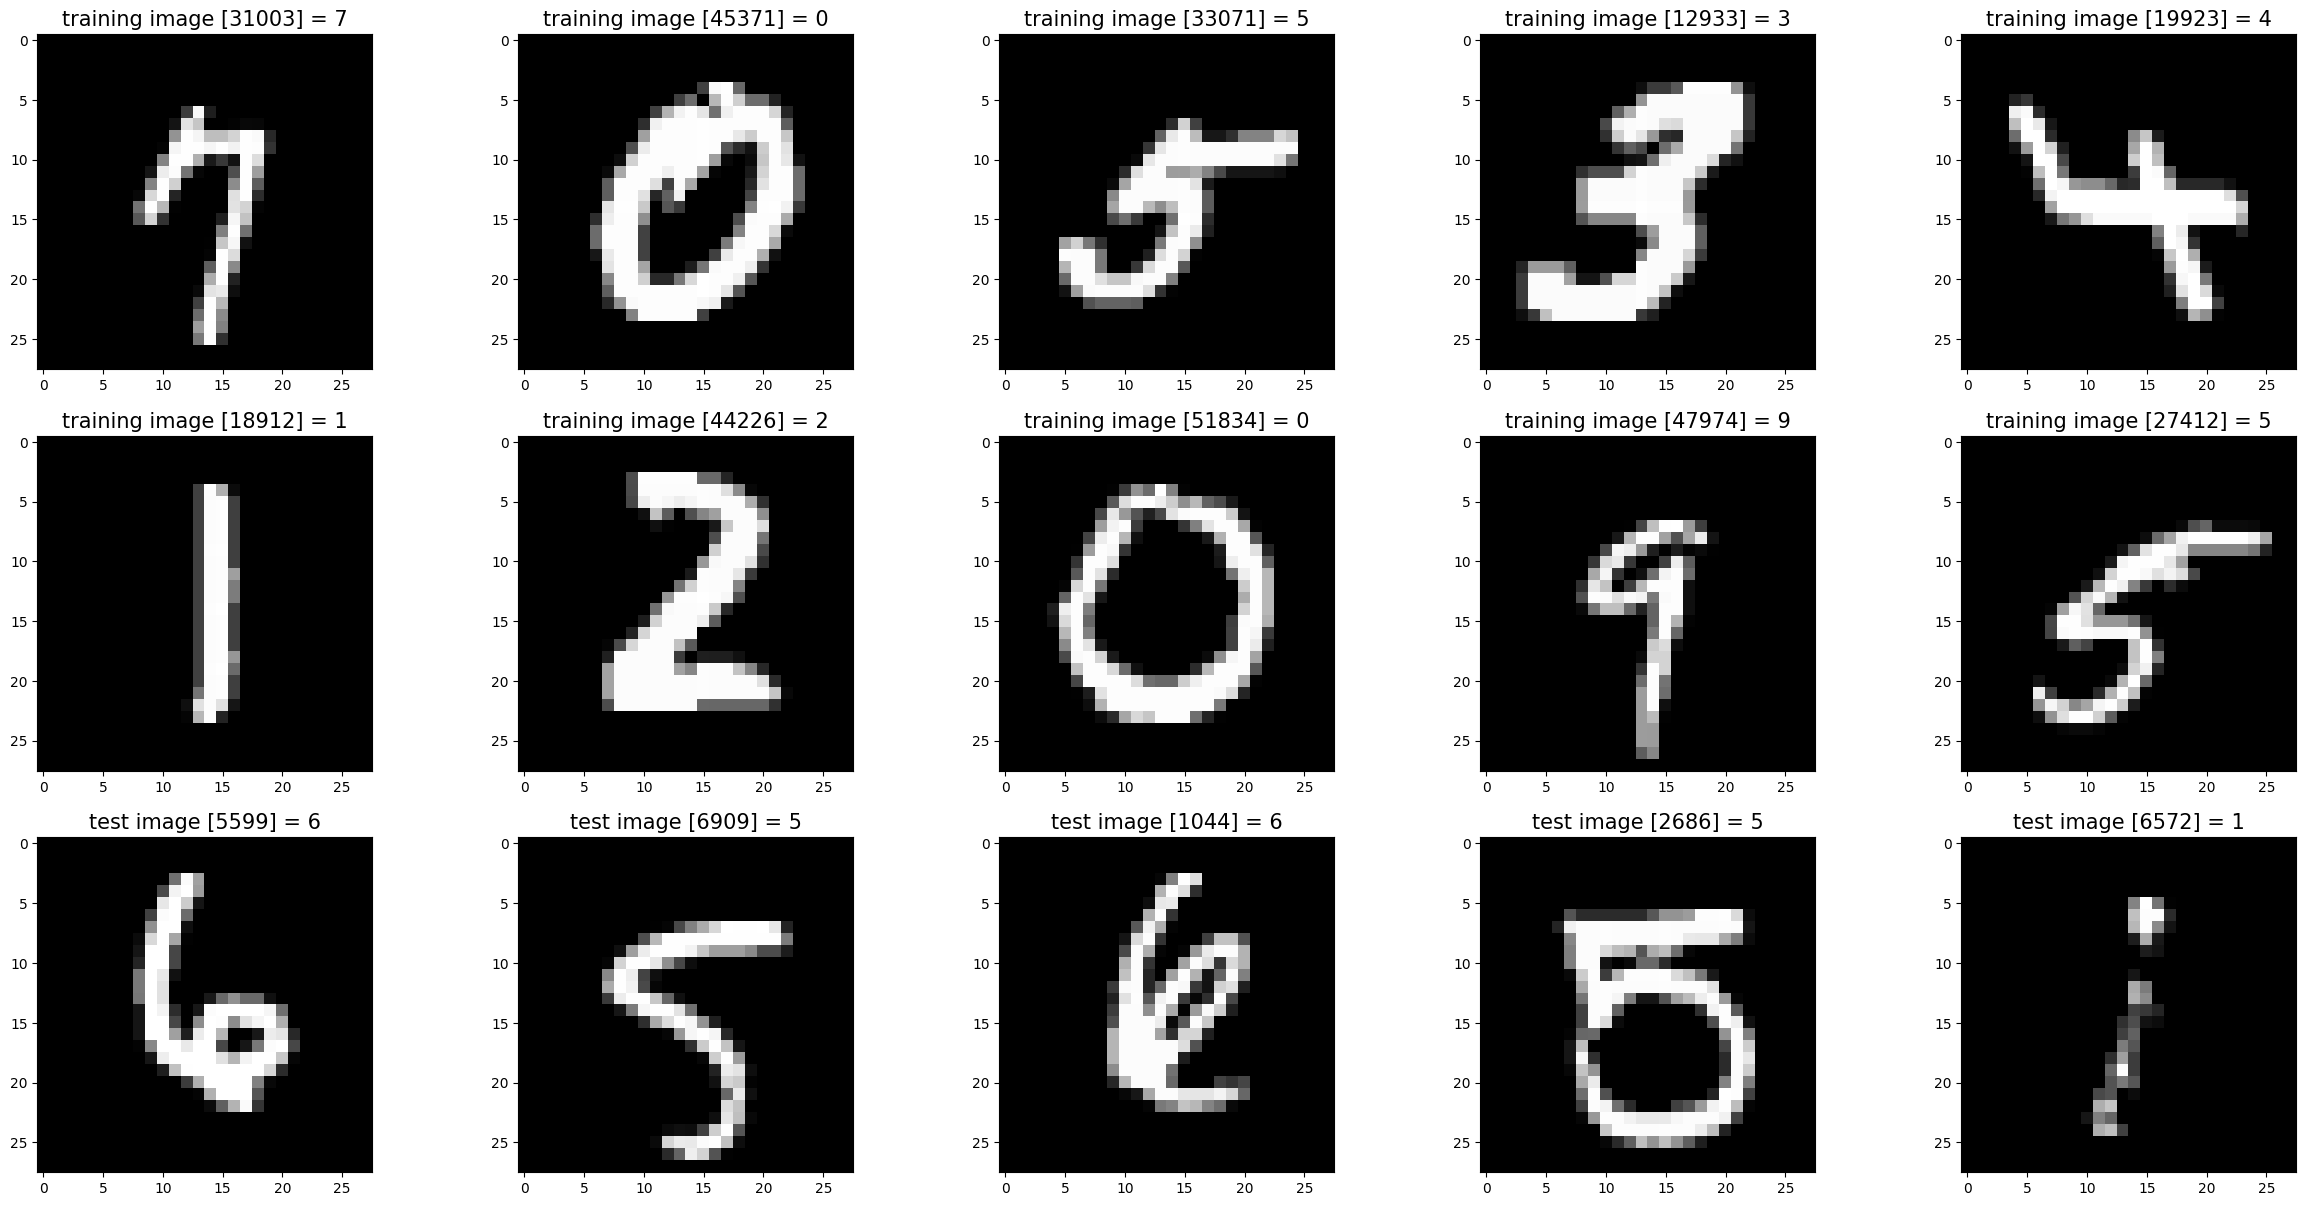

In [3]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

#### Предобработка данных

Нормализуем и отцентрируем входные данные. Приведём к float64. Сделаем векторы.

In [4]:
x_train = (np.array(x_train, dtype=np.float64) / 255.0 - 0.5) * 2
y_train = np.array(y_train)
x_test = (np.array(x_test, dtype=np.float64) / 255.0 - 0.5) * 2
y_test = np.array(y_test)

x_train = x_train.reshape((x_train.shape[0], -1))
x_test = x_test.reshape((x_test.shape[0], -1))

### Модель нейронной сети

#### Необходимые функции

Для обучения нейронной сети важно иметь доступ не только к самой функции активации, но и к её производной, поскольку производная используется на этапе обратного распространения ошибки. Чтобы упростить работу со слоями сети и обеспечить единый интерфейс, удобно создать базовый шаблонный класс, который объединяет в себе как функцию активации, так и её производную. Создадим такой класс и необходимые для нашей сети функции активации. Ещё раз выпишу формулы:

$$ReLU(x)=\max(0, x)$$
$$ReLU^\prime(x)=\begin{cases}1,\quad x>0\\0,\quad x\leq0\end{cases}$$
$$Softmax(z_i)=\frac{e^{z_i}}{\sum_{j=1}^Ke^{z_j}}$$
$$\frac{\partial L}{\partial z_i}=\hat y_i-y_i$$

In [5]:
class ActivationFunctionBasic:
    def activation(self, x):
        return x

    def activation_derivative(self, x):
        return 1


class ReLu(ActivationFunctionBasic):
    def activation(self, x):
        return np.maximum(0, x)

    def activation_derivative(self, x):
        return (x > 0).astype(float)


class Softmax(ActivationFunctionBasic):
    def activation(self, x):
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exps = np.exp(np.clip(x_shifted, -700, 700))
        return exps / np.sum(exps, axis=1, keepdims=True)

    def activation_derivative(self, x):
        return np.ones_like(x)  # Вообще говоря не нужно

Помимо функций активаций нам нужны функция ошибки кросс-энтропия и функция, которая считает точность.

$$L(\hat y, y)=−\sum_{i=1}^{C}y_{i}\log(\hat y_i)$$

In [6]:
def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    log_probs = -np.log(y_pred[np.arange(m), y_true] + 1e-8)
    return np.mean(log_probs)


def accuracy(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)
    if y_true.ndim > 1:
        true_labels = np.argmax(y_true, axis=1)
    else:
        true_labels = y_true
    return np.mean(pred_labels == true_labels)

#### Реализация главного класса

In [7]:
import time
import numpy.typing as npt


class Layer:
    def __init__(self, input_count: int, output_count: int, activation_function: ActivationFunctionBasic = None,
                 isInput: bool = False):
        """
        Класс Layer описывает один слой нейронной сети и задаёт его конфигурацию.

        Параметры:
            input_count (int): число входных нейронов (не используется для входного слоя).
            output_count (int): число нейронов в слое (размер выходного вектора).
            activation_function (ActivationFunctionBasic | None): функция активации и её производная.
                Если не указана, используется линейная активация.
            isInput (bool): флаг, обозначающий, является ли слой входным.

        Назначение:
            Класс служит описателем архитектуры слоя. Все вычисления производятся внутри NeuralNetwork.
        """

        self.isInput = isInput
        if self.isInput:
            self.input_count = None
        else:
            self.input_count = input_count
        self.output_count = output_count
        if activation_function is None:
            self.activation_function = ActivationFunctionBasic()
        else:
            self.activation_function = activation_function


class NeuralNetwork:
    def __init__(self, layers: list[Layer], loss_func=None, accuracy_func=None, learning_rate: float = 0.1):
        """
        Класс NeuralNetwork реализует многослойную нейронную сеть прямого распространения
        и обучение методом стохастического градиентного спуска.

        Параметры:
            layers (list[Layer]): список слоёв, определяющий архитектуру сети.
            loss_func (Callable): функция ошибки, принимающая (y_pred, y_true).
            accuracy_func (Callable): метрика accuracy, принимающая (y_pred, y_true).
            learning_rate (float): скорость обучения, должна быть положительной.

        Назначение:
            Создаёт структуру сети, инициализирует веса и смещения,
            а также сохраняет функции потерь и метрику точности.
        """

        self.layers = layers
        self.Ws = []
        self.bs = []
        self.init_weights()
        self.loss_func = loss_func
        self.accuracy_func = accuracy_func
        if learning_rate <= 0:
            raise
        self.learning_rate = learning_rate

    def init_weights(self):
        """
        Инициализация весов и смещений для всех слоёв (кроме входного).

        Процесс:
            - Для каждого слоя создаются матрицы весов с небольшими случайными значениями.
            - Смещения инициализируются нулями.
            - Проверяется согласованность размеров входов и выходов слоёв.
        """
        self.Ws = []
        self.bs = []
        prew_outputs = 0
        for layer in self.layers:
            if layer.isInput:
                prew_outputs = layer.output_count
                continue
            if layer.input_count is None or prew_outputs != layer.input_count:
                raise
            self.Ws.append(np.random.randn(layer.input_count, layer.output_count) * 0.05)
            self.bs.append(np.zeros((1, layer.output_count)))
            prew_outputs = layer.output_count

    def forward(self, x):
        """
        Выполняет прямое распространение входных данных через сеть.

        Параметры:
            x (np.ndarray): входные данные (размерность [batch_size, input_count]).

        Возвращает:
            lins (list[np.ndarray]): список линейных комбинаций до активации каждого слоя.
            acts (list[np.ndarray]): список выходов каждого слоя после применения функции активации.

        Назначение:
            Используется для вычисления предсказаний и хранения промежуточных значений
            для обратного распространения.
        """

        acts = [x]
        lins = []
        for i in range(len(self.Ws)):
            x = np.dot(x, self.Ws[i]) + self.bs[i]
            lins.append(x.copy())
            x = self.layers[i + 1].activation_function.activation(x)
            acts.append(x.copy())
        return lins, acts

    def predict(self, x):
        """
        Вычисляет выход сети для заданного входа.

        Параметры:
            x (np.ndarray): входные данные.

        Возвращает:
            np.ndarray: предсказания сети (выход последнего слоя).

        Назначение:
            Используется для оценки модели на тренировочных и тестовых данных.
        """

        _, ys = self.forward(x)
        return ys[-1]

    def backward(self, lins, acts, y):
        """
        Реализует обратное распространение ошибки (backpropagation).

        Параметры:
            lins (list[np.ndarray]): линейные комбинации каждого слоя из forward().
            acts (list[np.ndarray]): активации каждого слоя из forward().
            y (np.ndarray): истинные метки классов.

        Процесс:
            1. Вычисляет градиенты для последнего слоя с учётом softmax + кросс-энтропии.
            2. Вычисляет градиенты для скрытых слоёв по цепному правилу.
            3. Применяет gradient clipping для предотвращения взрывов градиентов.
            4. Обновляет веса и смещения с использованием стохастического градиентного спуска.
        """

        y_pred = acts[-1]
        m = y_pred.shape[0]
        delta = y_pred.copy()
        delta[np.arange(m), y] -= 1
        delta /= m
        dW = np.dot(acts[-2].T, delta)
        db = np.sum(delta, axis=0, keepdims=True)

        max_val = 1.0
        dW = np.clip(dW, -max_val, max_val)
        db = np.clip(db, -max_val, max_val)

        self.Ws[-1] -= self.learning_rate * dW
        self.bs[-1] -= self.learning_rate * db

        for i in range(len(self.layers) - 2, 0, -1):
            lin = lins[i - 1]
            sp = self.layers[i].activation_function.activation_derivative(lin)
            delta = np.dot(delta, self.Ws[i].T) * sp
            dW = np.dot(acts[i - 1].T, delta)
            db = np.sum(delta, axis=0, keepdims=True)

            dW = np.clip(dW, -max_val, max_val)
            db = np.clip(db, -max_val, max_val)

            self.Ws[i - 1] -= self.learning_rate * dW
            self.bs[i - 1] -= self.learning_rate * db

    def train(self, x_train, y_train):
        """
        Обучает сеть на одном мини-батче данных.

        Параметры:
            x_train (np.ndarray): входные данные батча.
            y_train (np.ndarray): истинные метки батча.

        Процесс:
            1. Вычисляет forward pass для батча.
            2. Вызывает backward для обновления весов и смещений.
        """

        lins, acts = self.forward(x_train)
        self.backward(lins, acts, y_train)

    def fit(self,
            x_train: npt.NDArray, y_train: npt.NDArray,
            x_test: npt.NDArray, y_test: npt.NDArray,
            epochs: int = 1,
            batch_size: int = 1,
            shafling: bool = True):
        """
        Обучает сеть на полном наборе данных в течение заданного числа эпох.

        Параметры:
            x_train (np.ndarray): обучающие данные.
            y_train (np.ndarray): метки обучающих данных.
            x_test (np.ndarray): тестовые данные.
            y_test (np.ndarray): метки тестовых данных.
            epochs (int): количество эпох обучения.
            batch_size (int): размер мини-батча.
            shafling (bool): перемешивать данные перед каждой эпохой.

        Процесс:
            1. Делит данные на мини-батчи.
            2. Для каждого батча выполняет train().
            3. После каждой эпохи вычисляет loss и accuracy на тренировочном наборе.
            4. В конце обучения оценивает сеть на тестовом наборе и выводит результаты.
        """

        if len(x_train) != len(y_train) or len(x_test) != len(y_test):
            raise
        else:
            size_train = len(x_train)
        if epochs < 0 or batch_size < 0:
            raise
        num_batches = int(np.ceil(size_train / batch_size))
        for epoch in range(1, epochs + 1):
            start_time = time.time()
            if shafling:
                perm = np.random.permutation(size_train)
                x_train = x_train[perm]
                y_train = y_train[perm]
            for i in range(num_batches):
                end_slice = (i + 1) * batch_size
                if end_slice >= size_train:
                    end_slice = size_train
                x_batch = x_train[i * batch_size: end_slice]
                y_batch = y_train[i * batch_size: end_slice]
                self.train(x_batch, y_batch)
            y_pred = self.predict(x_train)  # Тренировочный набор
            loss = self.loss_func(y_pred, y_train)
            accuracy = self.accuracy_func(y_pred, y_train)
            epoch_time = time.time() - start_time
            print(f"Эпоха {epoch}/{epochs} — Loss: {loss:.4f}, Accuracy: {accuracy * 100:.2f}%, Time: {epoch_time:.2f}s")
        y_pred = self.predict(x_test)  # Тестовый набор
        loss = self.loss_func(y_pred, y_test)
        accuracy = self.accuracy_func(y_pred, y_test)
        print(f"\nТест — Loss: {loss:.4f}, Accuracy: {accuracy * 100:.2f}%")

    def save(self, file_path):
        """
        Сохраняет параметры сети (веса и смещения) в файл.

        Параметры:
            file_path (str): путь к файлу для сохранения.
        """

        np.save(file_path, {'Ws': self.Ws, 'bs': self.bs}, allow_pickle=True)

    def load(self, file_path):
        """
        Загружает параметры сети (веса и смещения) из файла.

        Параметры:
            file_path (str): путь к файлу с сохранёнными параметрами.
        """

        data = np.load(file_path, allow_pickle=True).item()
        self.Ws = data['Ws']
        self.bs = data['bs']



Построим и запустим нашу нейронную сеть

In [8]:
layers = [
    Layer(None, 28 * 28, isInput=True),
    Layer(28 * 28, 300, ReLu()),
    Layer(300, 10, Softmax())
]
model = NeuralNetwork(layers, cross_entropy_loss, accuracy, learning_rate=0.01)
model.fit(x_train, y_train, x_test, y_test, 20, 64)

Эпоха 1/20 — Loss: 0.4068, Accuracy: 87.81%, Time: 3.61s
Эпоха 2/20 — Loss: 0.3251, Accuracy: 90.58%, Time: 3.59s
Эпоха 3/20 — Loss: 0.3022, Accuracy: 91.00%, Time: 3.52s
Эпоха 4/20 — Loss: 0.2727, Accuracy: 92.00%, Time: 3.56s
Эпоха 5/20 — Loss: 0.2543, Accuracy: 92.54%, Time: 3.63s
Эпоха 6/20 — Loss: 0.2298, Accuracy: 93.49%, Time: 3.40s
Эпоха 7/20 — Loss: 0.2083, Accuracy: 94.20%, Time: 3.36s
Эпоха 8/20 — Loss: 0.2046, Accuracy: 94.18%, Time: 3.39s
Эпоха 9/20 — Loss: 0.1849, Accuracy: 94.83%, Time: 3.31s
Эпоха 10/20 — Loss: 0.1938, Accuracy: 94.25%, Time: 3.31s
Эпоха 11/20 — Loss: 0.1719, Accuracy: 94.99%, Time: 3.28s
Эпоха 12/20 — Loss: 0.1586, Accuracy: 95.47%, Time: 3.29s
Эпоха 13/20 — Loss: 0.1528, Accuracy: 95.69%, Time: 3.35s
Эпоха 14/20 — Loss: 0.1502, Accuracy: 95.77%, Time: 3.27s
Эпоха 15/20 — Loss: 0.1416, Accuracy: 96.01%, Time: 3.28s
Эпоха 16/20 — Loss: 0.1271, Accuracy: 96.41%, Time: 3.32s
Эпоха 17/20 — Loss: 0.1239, Accuracy: 96.47%, Time: 3.25s
Эпоха 18/20 — Loss: 0.1

In [9]:
# model.save("my_model")